In [1]:
import pandas as pd

In [2]:
uri = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\usina.csv'
df = pd.read_csv(uri, sep=',')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
y = df['PE']
X = df.drop('PE', axis=1)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

In [5]:
import seaborn as sns

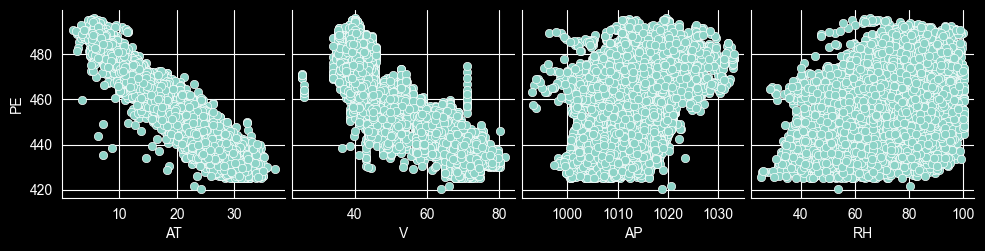

In [6]:
sns.pairplot(data=df, y_vars=['PE'], x_vars=['AT', 'V', 'AP', 'RH'])

In [7]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train)

In [8]:
modelo = sm.OLS(y_train, X_train).fit()

In [9]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.040e+04
Date:                Wed, 14 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:18:33   Log-Likelihood:                -18234.
No. Observations:                6219   AIC:                         3.648e+04
Df Residuals:                    6214   BIC:                         3.651e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        466.3212     12.001     38.857      0.0

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
vif_1 = pd.DataFrame()
vif_1["variavel"] = X_train.columns

vif_1["vif"] = [variance_inflation_factor(X_train[X_train.columns].values, i)
                          for i in range(len(X_train.columns))]

print(vif_1)

  variavel           vif
0    const  43411.581800
1       AT      5.976297
2        V      3.928134
3       AP      1.446768
4       RH      1.715624


In [12]:
import plotly.express as px

In [13]:
y_previsto_train =  modelo.predict(X_train)
fig = px.scatter(x=y_previsto_train, y=y_train,
                 title='Previsão X Real',
                 labels={'x':'Preço previsto','y':'Preço real'})
fig.show()

In [14]:
residuos = modelo.resid
fig = px.scatter(x=y_previsto_train, y=residuos,
                 title='Previsão X Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()